<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/ANALISE_ESTRUTURAL_VIGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Estrutural da Viga Metálica

## Objetivo
Verificar se a viga metálica de 6 m em aço ASTM A36 suporta a carga de 12 kN aplicada no centro.

## Etapas do Programa
1. Definição dos dados da viga (comprimento, carga, material, seção).
2. Cálculo das propriedades geométricas (momento de inércia).
3. Determinação das reações de apoio (equações de equilíbrio).
4. Cálculo dos esforços internos (cortante e momento).
5. Verificação da tensão máxima (flexão).
6. Cálculo da flecha máxima (deslocamento).
7. Comparação com limites normativos (resistência e deslocamento).
8. Apresentação dos resultados em tabela.
9. Geração dos diagramas de esforço cortante e momento fletor.
10. Conclusão automática sobre a viabilidade estrutural.

## Resultados esperados
- Reações de apoio: 6 kN cada
- Momento máximo: 18 kN·m
- Tensão máxima: σ < 250 MPa (seguro)
- Flecha máxima: δ < L/250 (aceitável)


RESULTADOS DA ANÁLISE:

                Grandeza         Valor Unidade
0  Reação Apoio Esquerdo  6.000000e+03       N
1   Reação Apoio Direito  6.000000e+03       N
2            Momento Máx  1.800000e+04     N·m
3           Cortante Máx  6.000000e+03       N
4             Tensão Máx  3.375000e+06      Pa
5             Flecha Máx  2.531250e-04       m


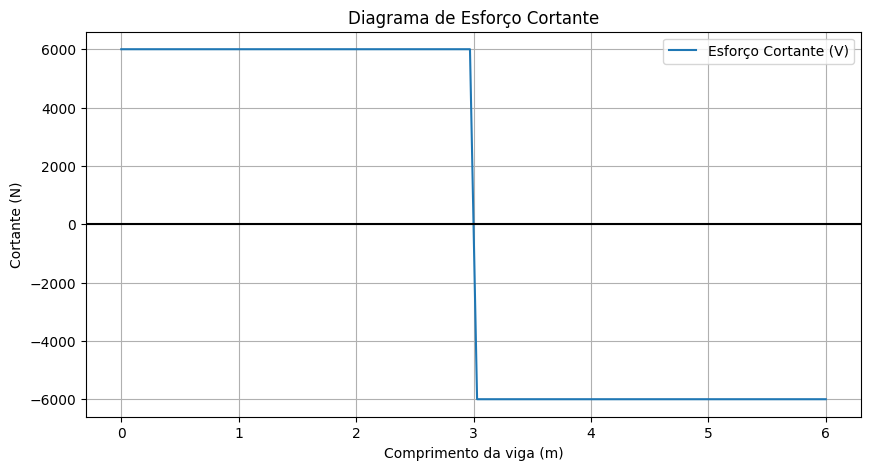

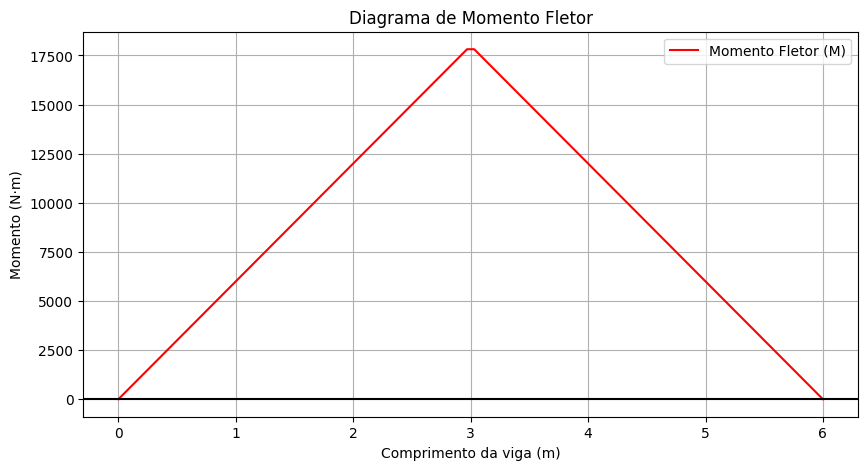

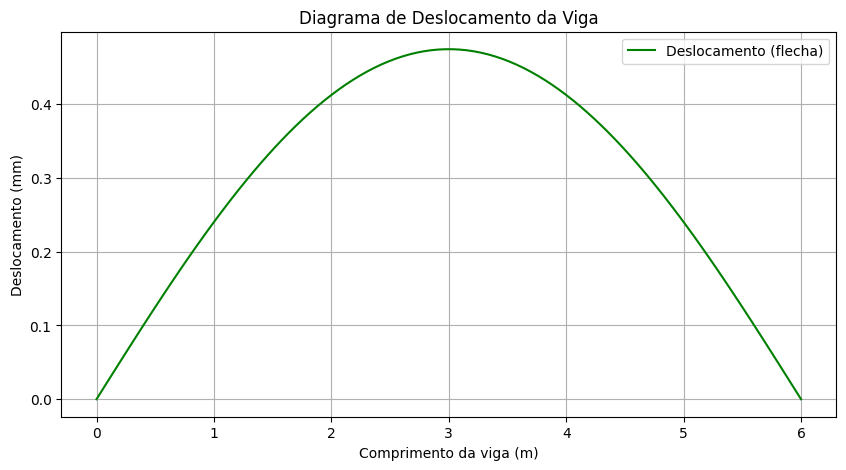


CONCLUSÃO:
✅ A viga é estruturalmente viável: atende aos critérios de resistência e deslocamento.


In [3]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# ANÁLISE ESTRUTURAL DE UMA VIGA SIMPLESMENTE APOIADA
# ============================================================
# Contexto:
# A empresa deseja instalar um equipamento de 12 kN sobre uma viga metálica.
# Precisamos verificar se a viga suporta o carregamento em termos de:
# - Reações de apoio
# - Esforços internos (cortante e momento)
# - Tensão máxima
# - Deslocamento máximo (flecha)
# ============================================================
# # Análise Estrutural da Viga Metálica

## Objetivo
# Verificar se a viga metálica de 6 m em aço ASTM A36 suporta a carga de 12 kN aplicada no centro.

## Etapas do Programa
# 1. Definição dos dados da viga (comprimento, carga, material, seção).
# 2. Cálculo das propriedades geométricas (momento de inércia).
# 3. Determinação das reações de apoio (equações de equilíbrio).
# 4. Cálculo dos esforços internos (cortante e momento).
# 5. Verificação da tensão máxima (flexão).
# 6. Cálculo da flecha máxima (deslocamento).
# 7. Comparação com limites normativos (resistência e deslocamento).
# 8. Apresentação dos resultados em tabela.
# 9. Geração dos diagramas de esforço cortante e momento fletor.
#10. Conclusão automática sobre a viabilidade estrutural.

## Resultados esperados
#- Reações de apoio: 6 kN cada
#- Tensão máxima: σ < 250 MPa (seguro)
#- Flecha máxima: δ < L/250 (aceitável)
# -----------------------------
# 1. Definição dos dados da viga
# -----------------------------
L = 6.0       # comprimento da viga em metros
P = 12e3      # carga concentrada em Newtons (12 kN)
E = 200e9     # módulo de elasticidade do aço ASTM A36 em Pa
b, h = 0.20, 0.40  # seção retangular da viga (20 cm x 40 cm)

# Justificativa:
# Escolhemos uma seção retangular para exemplificar. Em projetos reais,
# seria usado um perfil metálico (I ou H), mas aqui simplificamos.

# -----------------------------
# 2. Propriedades geométricas
# -----------------------------
I = (b * h**3) / 12  # momento de inércia da seção
c = h / 2            # distância até a fibra mais distante

# Justificativa:
# O momento de inércia mede a resistência da seção à flexão.
# Quanto maior o I, menor será a deformação da viga.

# -----------------------------
# 3. Reações de apoio
# -----------------------------
RA = RB = P / 2

# Justificativa:
# Como a carga está aplicada no centro da viga e os apoios são simétricos,
# cada apoio recebe metade da carga.

# -----------------------------
# 4. Esforços internos
# -----------------------------
Mmax = P * L / 4   # momento máximo no centro
Vmax = P / 2       # esforço cortante máximo nos apoios

# Justificativa:
# Fórmulas clássicas da resistência dos materiais para viga simplesmente apoiada
# com carga concentrada no meio do vão.

# -----------------------------
# 5. Tensão máxima
# -----------------------------
sigma = Mmax * c / I

# Justificativa:
# Fórmula da flexão: σ = M * c / I
# Compara-se com a tensão admissível do aço ASTM A36 (~250 MPa).

# -----------------------------
# 6. Deslocamento máximo (flecha)
# -----------------------------
delta_max = (P * L**3) / (48 * E * I)

# Justificativa:
# Fórmula clássica para flecha máxima em viga simplesmente apoiada
# com carga concentrada no centro.

# -----------------------------
# 7. Limites normativos
# -----------------------------
sigma_limite = 250e6   # limite de tensão do aço ASTM A36 (Pa)
delta_limite = L / 250 # limite de flecha (m), norma usual

# -----------------------------
# 8. Resultados em tabela
# -----------------------------
dados = {
    "Grandeza": ["Reação Apoio Esquerdo", "Reação Apoio Direito", "Momento Máx", "Cortante Máx", "Tensão Máx", "Flecha Máx"],
    "Valor": [RA, RB, Mmax, Vmax, sigma, delta_max],
    "Unidade": ["N", "N", "N·m", "N", "Pa", "m"]
}
df = pd.DataFrame(dados)
print("\nRESULTADOS DA ANÁLISE:\n")
print(df)

# -----------------------------
# 9. Gráfico de esforço cortante
# -----------------------------
x = np.linspace(0, L, 100)
V = np.piecewise(x, [x < L/2, x >= L/2], [RA, -RB])

plt.figure(figsize=(10,5))
plt.plot(x, V, label="Esforço Cortante (V)")
plt.axhline(0, color='black')
plt.title("Diagrama de Esforço Cortante")
plt.xlabel("Comprimento da viga (m)")
plt.ylabel("Cortante (N)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 10. Gráfico de momento fletor
# -----------------------------
M = np.piecewise(x, [x < L/2, x >= L/2], [lambda x: RA*x, lambda x: RB*(L-x)])

plt.figure(figsize=(10,5))
plt.plot(x, M, label="Momento Fletor (M)", color="red")
plt.axhline(0, color='black')
plt.title("Diagrama de Momento Fletor")
plt.xlabel("Comprimento da viga (m)")
plt.ylabel("Momento (N·m)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 11. Gráfico de deslocamento (flecha)
# -----------------------------
# Fórmula da flecha para viga simplesmente apoiada com carga concentrada no centro:
# y(x) = (P * x * (L**3 - 2*L*x**2 + x**3)) / (48 * E * I)
# Essa equação fornece o deslocamento em cada ponto da viga.

def deslocamento(x, P, L, E, I):
    return (P * x * (L**3 - 2*L*x**2 + x**3)) / (48 * E * I)

y = deslocamento(x, P, L, E, I)

plt.figure(figsize=(10,5))
plt.plot(x, y*1000, label="Deslocamento (flecha)", color="green")  # convertido para mm
plt.title("Diagrama de Deslocamento da Viga")
plt.xlabel("Comprimento da viga (m)")
plt.ylabel("Deslocamento (mm)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 12. Conclusão automática
# -----------------------------
print("\nCONCLUSÃO:")
if sigma < sigma_limite and delta_max < delta_limite:
    print("✅ A viga é estruturalmente viável: atende aos critérios de resistência e deslocamento.")
else:
    print("⚠️ A viga NÃO atende aos critérios: revisar seção ou material.")